# Titanic Data-Set Performing EDA

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [9]:
# Loading the Data 
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Understand the Data-set

In [10]:
# Shape (rows, columns)
print(f"Dataset has {df.shape[0]} passengers and {df.shape[1]} features")

# Column names
print("\nColumns:", df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Summary statistics
df.describe()

Dataset has 891 passengers and 12 features

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Checking the Missing Values 

In [ ]:
# Count missing values
missing = df.isnull().sum() # Here df is the DataFrame we are working with
print(missing[missing > 0])

# Percentage missing
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage missing:")
print(missing_percent[missing_percent > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64

Percentage missing:
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


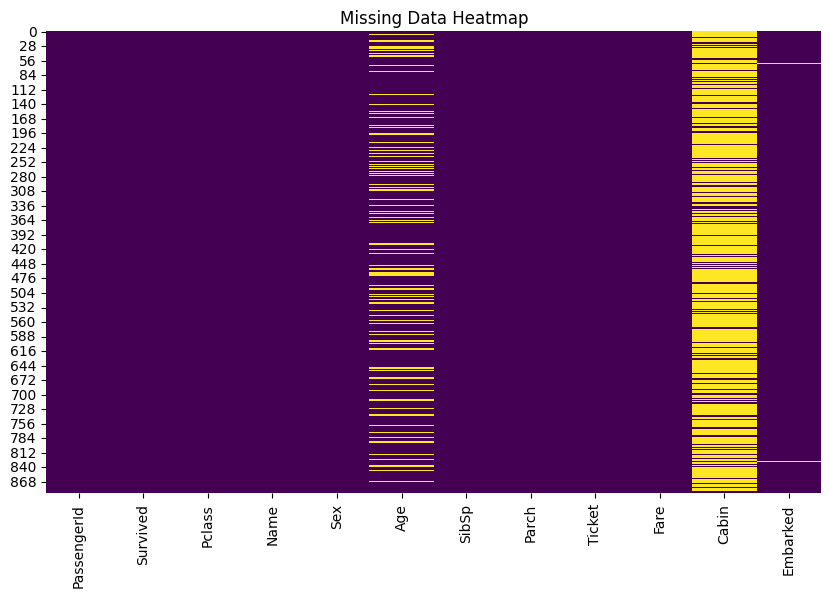

In [ ]:
# Visualize missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Clean the Data-set

In [13]:
# Fill age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill embarked with mode (most common)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop cabin (too many missing)
df.drop('Cabin', axis=1, inplace=True)

# Verify
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\Muhammad Saad Ullah\AppData\Local\Temp\ipykernel_11248\1913945547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Muhammad Saad Ullah\AppData\Local\Temp\ipykernel_11248\1913945547.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

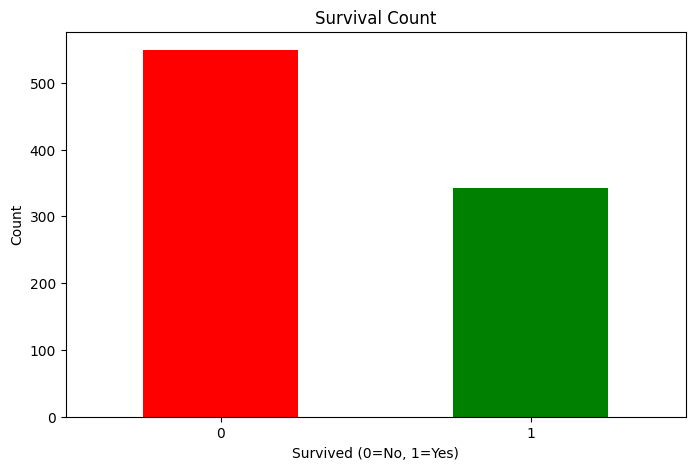

Survival rate: 38.38%


In [ ]:
# Overall survival
survived = df['Survived'].value_counts()
plt.figure(figsize=(8,5))
survived.plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Percentage
survival_rate = (df['Survived'].sum() / len(df)) * 100
print(f"Survival rate: {survival_rate:.2f}%")


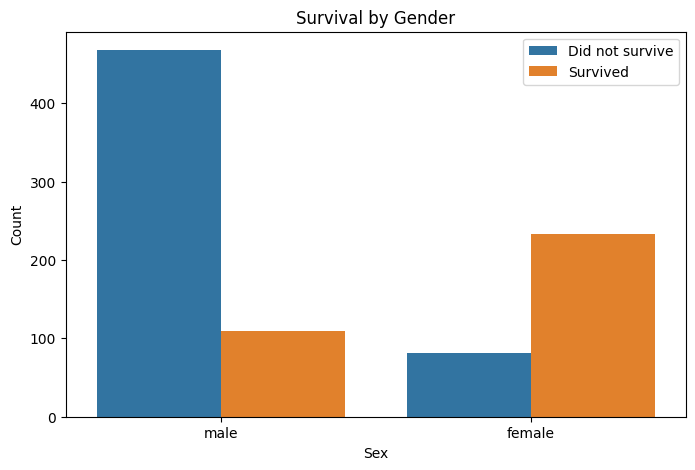


Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [15]:
# Survival by Gender
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.ylabel('Count')
plt.legend(['Did not survive', 'Survived'])
plt.show()

# Percentage by gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("\nSurvival rate by gender:")
print(gender_survival)

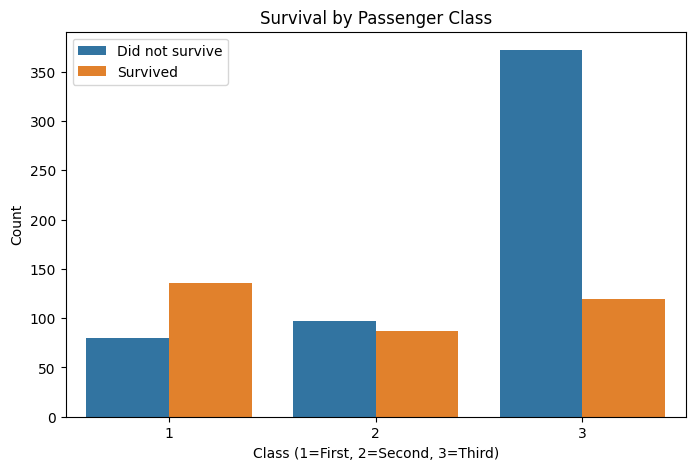

In [16]:
# Survival by Class
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.legend(['Did not survive', 'Survived'])
plt.show()

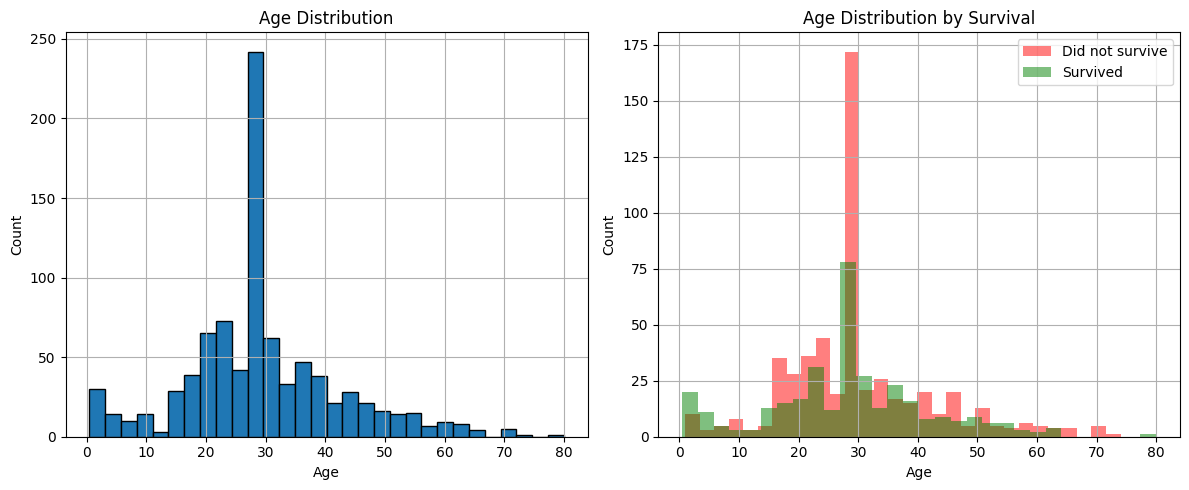

In [17]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Survival by age
plt.subplot(1,2,2)
df[df['Survived']==0]['Age'].hist(bins=30, alpha=0.5, label='Did not survive', color='red')
df[df['Survived']==1]['Age'].hist(bins=30, alpha=0.5, label='Survived', color='green')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# Key Insights
print("KEY INSIGHTS FROM TITANIC DATA:")
print("="*50)
print(f"1. Overall survival rate: {(df['Survived'].mean()*100):.2f}%")
print(f"2. Female survival rate: {(df[df['Sex']=='female']['Survived'].mean()*100):.2f}%")
print(f"3. Male survival rate: {(df[df['Sex']=='male']['Survived'].mean()*100):.2f}%")
print(f"4. First-class survival: {(df[df['Pclass']==1]['Survived'].mean()*100):.2f}%")
print(f"5. Third-class survival: {(df[df['Pclass']==3]['Survived'].mean()*100):.2f}%")
print(f"6. Children (<18) survival: {(df[df['Age']<18]['Survived'].mean()*100):.2f}%")

KEY INSIGHTS FROM TITANIC DATA:
1. Overall survival rate: 38.38%
2. Female survival rate: 74.20%
3. Male survival rate: 18.89%
4. First-class survival: 62.96%
5. Third-class survival: 24.24%
6. Children (<18) survival: 53.98%
